# Behavioral Social Media Data: Exploratory Data Analysis

This notebook demonstrates how to load, structure, and visualize alternative behavior data (Reddit comments) as part of the GWP1 assignment. We'll use the provided `reddit_comments.csv` file from Module 4.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/anirudh/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 1. Loading the Data
We load the historical Reddit comments. Since `bull_count`, `bear_count`, and `sia` (Sentiment Intensity Analyzer) scores are already computed in our CSV, we don't need to re-run the intensive NLP algorithms, but the methodology remains identical to Lab 04.

In [2]:
# Load data from the M4 directory
df = pd.read_csv('../M4 Alternative Data/reddit_comments.csv')

# Convert timestamps to datetime
df['created_utc'] = pd.to_datetime(df['created_utc'])
df.set_index('created_utc', inplace=True)
df.sort_index(inplace=True)

df.head()

,text,subreddit,tokenized,bull_count,bear_count,sia
created_utc,,,,,,
2024-07-01 09:17:47,\n**TL;DR**\n\n>Metaplanet's recent Bitcoin pu...,cryptocurrency,"['*', '*', 'tl', ';', 'dr', '*', '*', '>', 'me...",0,0,0.4939
2024-07-01 09:20:20,"tldr; Metaplanet, a Tokyo Stock Exchange-liste...",cryptocurrency,"['tldr', ';', 'metaplanet', ',', 'a', 'tokyo',...",0,0,0.9287
2024-07-01 09:44:39,Me likey,cryptocurrency,"['me', 'likey']",0,0,0.0000
2024-07-01 10:20:49,Governments shouldn't be allowed to buy crypto,cryptocurrency,"['governments', 'should', ""n't"", 'be', 'allowe...",1,0,0.0000
2024-07-01 10:28:17,Why? Isnt it a free market,cryptocurrency,"['why', '?', 'isnt', 'it', 'a', 'free', 'market']",0,0,-0.4023


## 2. Aggregating Sentiment
We aggregate the daily word counts of bullish and bearish keywords, calculate the daily 'net' sentiment (Bull minus Bear), and apply a 7-day rolling window to smooth the data.

In [3]:
daily_sentiment = df[['bull_count', 'bear_count']].resample('D').sum()

# Calculate Bull - Bear metric
bull_minus_bear = daily_sentiment['bull_count'] - daily_sentiment['bear_count']

# Apply 7-day rolling mean
smoothed_sentiment = bull_minus_bear.rolling('7D').mean()
smoothed_sentiment.dropna(inplace=True)

## 3. Benchmarking Market Price
We retrieve the BTC-USD price corresponding to our sentiment timeline using `yfinance`.

In [4]:
# Download BTC-USD data for the identical time period
start_dt = df.index.min().strftime('%Y-%m-%d')
end_dt = df.index.max().strftime('%Y-%m-%d')

# We add a 1-day buffer to end_dt to ensure data bounds overlap perfectly
btcusd = yf.Ticker('BTC-USD').history(start=start_dt, end=end_dt)['Close']

## 4. Visualizing Sentiment vs Price
We overlay the smoothed sentiment alongside the BTC-USD price to observe any leading, lagging, or coincident correlations.

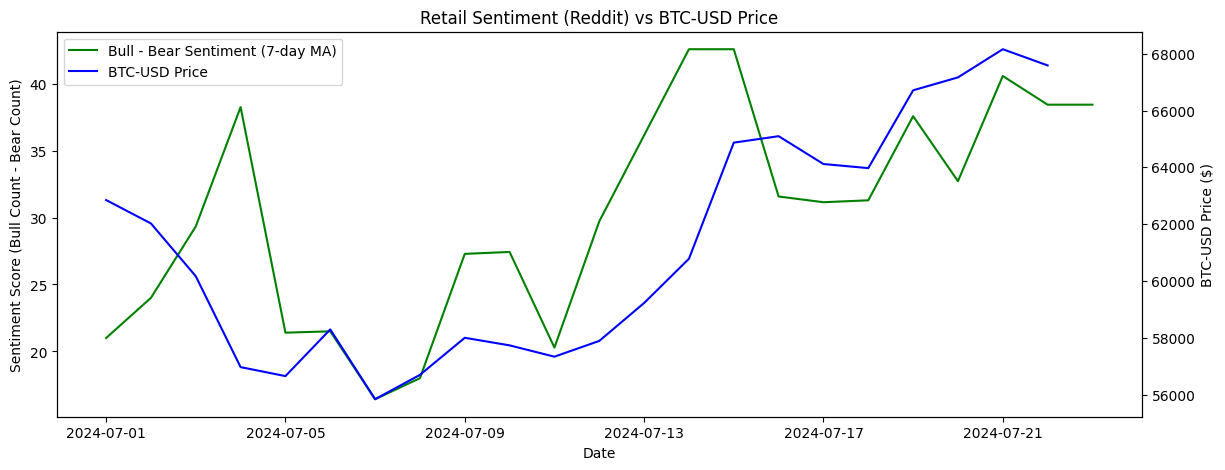

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Plotting
ax1.plot(smoothed_sentiment, color='green', label='Bull - Bear Sentiment (7-day MA)')
ax2.plot(btcusd, color='blue', label='BTC-USD Price')

# Formatting
ax1.set_ylabel('Sentiment Score (Bull Count - Bear Count)')
ax2.set_ylabel('BTC-USD Price ($)')
ax1.set_xlabel('Date')

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Retail Sentiment (Reddit) vs BTC-USD Price')
plt.show()